# IMPORTING LIBRARIES

In [1]:
#import library 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc,precision_recall_curve,roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from imblearn.over_sampling import SMOTE
import imblearn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import ClusterCentroids
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore')

In [2]:
# # with ggender & age-related features:
# data=pd.read_csv('cleaned_G.csv')
# data.head(10)
# data["Flag"].value_counts()

# # Drop the sampled rows from the DataFrame
# # x = x.drop(rows_to_delete.index)


In [3]:
# y_zero_rows = data[data['Flag'] == 0]
# # Randomly sample 93% of those rows
# rows_to_delete = y_zero_rows.sample(frac=0.93, random_state=42)
# print(rows_to_delete.shape)

# data = data.drop(rows_to_delete.index)
# print(data.shape)
# data["Flag"].value_counts()

In [4]:
# # without gender-related features:
# cols=["Fasting","A1c","DiabetesStatusUsingA1c","AbdominalCircumferenceStatus",
#       "Mammography","PapSmear","ClinicalBreastExam","ColorectalExam","DiabetesDuringPregnancyHistory"]
# data_cleaned=data.drop(columns=cols)
# data_cleaned.isnull().sum()

In [5]:
# data_cleaned.to_csv('cleaned-sample.csv',index=False)

In [6]:
df = pd.read_csv('cleaned-sample.csv')

# MORE DATA PREPROCESSING

**SPLITTING DATA SET INTO FEATURES AND LABELS**

In [7]:
#split dataset into two sets: 1. feature set 2. class
cols=['EmergencyReferral', 'HighRisk', 'Flag_Mix','Flag_E', 'Flag']
X=df.drop(columns=cols)
#class
y=df["Flag"]
#X.head()

In [8]:
X.shape

(12057, 40)

**CHECK CLASS DISTRIBUTION--CLASS IMBALANCE**

In [9]:
# detect class imbalance
df["Flag"].value_counts()

Flag
0.0    8665
1.0    3392
Name: count, dtype: int64

**SPLITTING DATASET INTO TRAIN-TEST SPLITS**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

**APPLYING UNDERSAMPLING METHOD FOR IMBALANCED CLASS**

In [11]:
import imblearn
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [12]:
#check the class distribution
import collections
print(sorted(collections.Counter(y_resampled).items()))

[(0.0, 2416), (1.0, 2416)]


**APPLYING RANDOM FOREST ALGORITHM TO SELECT THE IMPORTANT FEATURES**

In [13]:
cols=['SBP',
      'DBP',                                      
 'BPAssessment',                             
  'GLU',                                      
  'DiabetesStatusUsingGlucose',               
  'DMAssessment',                            
  'BMI',                                      
  'Age',                                      
  'LDL',                                     
 'TCHOL',                                     
 'WEIGHT',                                   
 'AbdominalCir',                             
 'TGS',                                       
 'AST',                                       
 'ALT',                                      
 'DiabetesHistory',                           
 'TC:HDL_RATIO',                            
 'HEIGHT',                                   
 'HDL',                                    
 'METS_Risks',                                
 'Activity',                                 
 'BMIAssessment',                             
 'Smoking',                                  
 'HypertensionHistory',                       
 'LDLAssessment',                          
 'DyslipidemiaStatus',                        
 'CholesterolMedication',                     
 'HypertensionMedication',                    
 'HDLAssessment',                             
 'Gender',                                    
 'AsthmaHistory',                          
 'SmokelessTobacco',                          
 'TGSAssessment',                           
 'Alcohol',                                  
 'HeartDiseaseHistory',                    
 'HighCholesterolHistory',                    
 'DiabetesMedication',                        
 'COPDHistory',                               
 'HeartFailureHistory',                       
 'CoronaryArteryHistory']

In [14]:
cols = np.array(cols)

## homework start here 

 1) SBP                                       0.106485
 2) BPAssessment                              0.084861
 3) DBP                                       0.083172
 4) GLU                                       0.052733
 5) BMI                                       0.043310
 6) DiabetesStatusUsingGlucose                0.040857
 7) AbdominalCir                              0.039328
 8) DiabetesHistory                           0.039164
 9) TGS                                       0.037386
10) DMAssessment                              0.036112
11) Age                                       0.036042
12) TCHOL                                     0.035603
13) LDL                                       0.034746
14) AST                                       0.034434
15) WEIGHT                                    0.032480
16) ALT                                       0.031571
17) HDL                                       0.031290
18) METS_Risks                                0.028940
19) TC:HDL

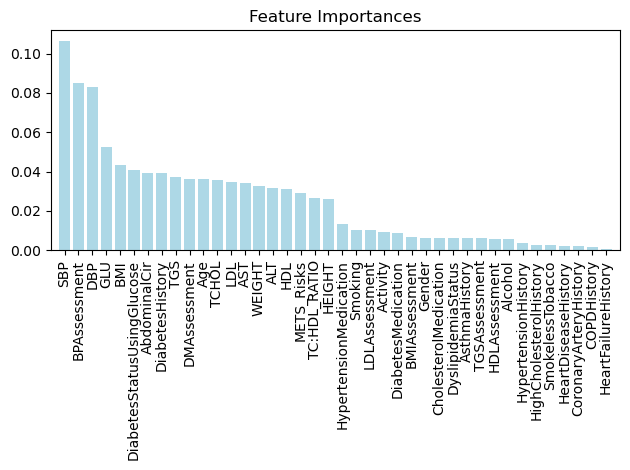

In [16]:
# Feature selection method using RF

from sklearn.ensemble import RandomForestClassifier

feat_labels = X.columns[:]

forest = RandomForestClassifier(n_estimators=10,
                                random_state=0,
                                n_jobs=-1)

forest.fit(X_resampled, y_resampled)
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X_resampled.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 41, 
                            feat_labels[indices[f]], 
                            importances[indices[f]]))

plt.title('Feature Importances')
plt.bar(range(X_resampled.shape[1]), 
        importances[indices],
        color='lightblue', 
        align='center')

plt.xticks(range(X_resampled.shape[1]), 
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_resampled.shape[1]])
plt.tight_layout()
#plt.savefig('./random_forest.png', dpi=300)
plt.show()

**Feature importance through coefficients**

In [17]:
from sklearn.linear_model import RidgeCV

 1) SBP                                       0.005881
 2) BPAssessment                              0.029426
 3) DBP                                       0.006009
 4) GLU                                       0.001369
 5) BMI                                       0.014456
 6) DiabetesStatusUsingGlucose                0.094157
 7) AbdominalCir                              0.002937
 8) DiabetesHistory                           0.183320
 9) TGS                                       0.000267
10) DMAssessment                              0.124298
11) Age                                       0.003078
12) TCHOL                                     0.000525
13) LDL                                       0.000358
14) AST                                       0.000678
15) WEIGHT                                    0.002030
16) ALT                                       0.000361
17) HDL                                       0.000233
18) METS_Risks                                0.007669
19) TC:HDL

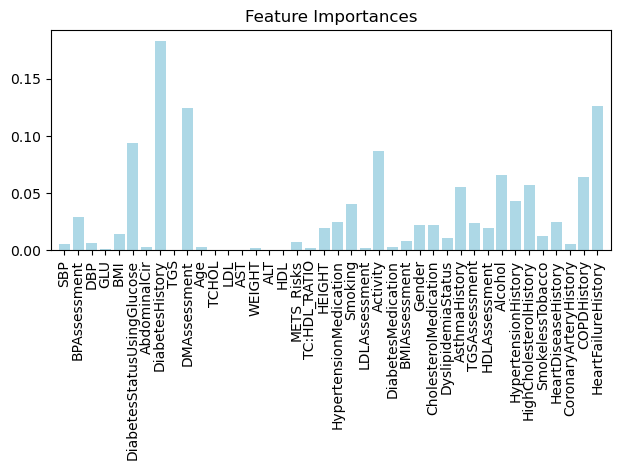

In [18]:
ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X_resampled, y_resampled)
importance = np.abs(ridge.coef_)

indices_1 = np.argsort(importance)[::-1]

for f in range(X_resampled.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 41, 
                            feat_labels[indices[f]], 
                            importance[indices[f]]))

plt.title('Feature Importances')
plt.bar(range(X_resampled.shape[1]), 
        importance[indices],
        color='lightblue', 
        align='center')

plt.xticks(range(X_resampled.shape[1]), 
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_resampled.shape[1]])
plt.tight_layout()
#plt.savefig('./random_forest.png', dpi=300)
plt.show()

**Seqential feature selection (Backward & Forward)**

In [19]:
from sklearn.feature_selection import SequentialFeatureSelector
from time import time

tic_fwd = time()
sfs_forward = SequentialFeatureSelector(
    ridge, n_features_to_select=15, direction="forward"
).fit(X_resampled, y_resampled)
toc_fwd = time()

tic_bwd = time()
sfs_backward = SequentialFeatureSelector(
    ridge, n_features_to_select=15, direction="backward"
).fit(X_resampled, y_resampled)
toc_bwd = time()

print(
    "Features selected by forward sequential selection: "
    f"{cols[sfs_forward.get_support()]}"
)
print(f"Done in {toc_fwd - tic_fwd:.3f}s")
print(
    "Features selected by backward sequential selection: "
    f"{cols[sfs_backward.get_support()]}"
)
print(f"Done in {toc_bwd - tic_bwd:.3f}s")

Features selected by forward sequential selection: ['DBP' 'BPAssessment' 'GLU' 'DiabetesStatusUsingGlucose' 'AbdominalCir'
 'TC:HDL_RATIO' 'HEIGHT' 'METS_Risks' 'Smoking' 'HypertensionHistory'
 'DyslipidemiaStatus' 'HypertensionMedication' 'HDLAssessment'
 'AsthmaHistory' 'Alcohol']
Done in 13.748s
Features selected by backward sequential selection: ['DBP' 'BPAssessment' 'GLU' 'DiabetesStatusUsingGlucose' 'AbdominalCir'
 'TGS' 'AST' 'HEIGHT' 'Smoking' 'HypertensionHistory' 'DyslipidemiaStatus'
 'HypertensionMedication' 'HDLAssessment' 'AsthmaHistory' 'Alcohol']
Done in 172.784s


**Taking the most important columns based on any one of the above feature selection methods**

## Please write code for your own feature selection method:

In [20]:
X_resampled=pd.DataFrame(X_resampled,columns=X.columns)
X_test=pd.DataFrame(X_test,columns=X.columns)

In [21]:
cols=['SBP', 'DBP', 'BPAssessment', 'GLU', 'BMI', 'TGS', 'Age', 'TCHOL', 'AST', 'LDL', 'ALT', 'WEIGHT', 'DMAssessment', 'AbdominalCir', 'METS_Risks', 'DiabetesStatusUsingGlucose']
X_resampled=X_resampled[cols]
X_test=X_test[cols]

**Feature Scaling**

In [22]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_resampled = mms.fit_transform(X_resampled)
X_test = mms.fit_transform(X_test)

# MODEL BUILDING 

**LOGISTIC REGRESSION**

In [23]:
def lr_fit(X_resampled, y_resampled,X_test,y_test):
    lr = LogisticRegression(C=100, max_iter= 300,penalty= 'l2')
    clf = lr.fit(X_resampled, y_resampled)
    clf_predicted = clf.predict(X_test)
    ConfusionMatrix_Report(y_test=y_test,y_predicted=clf_predicted)
    y_score = lr.decision_function(X_test)
    ROC_decison_function(y_test, y_score)

**SUPPORT VECTOR MACHINE**

In [24]:
def svm_rbf_fit(X_resampled, y_resampled,X_test,y_test):
    svm_rbf = SVC(kernel='linear', C=10,gamma=0.001,probability=True)
    clf = svm_rbf.fit(X_resampled, y_resampled)
    clf_predicted = clf.predict(X_test)
    ConfusionMatrix_Report(y_test=y_test,y_predicted=clf_predicted)
    y_score = svm_rbf.decision_function(X_test)
    ROC_decison_function(y_test, y_score)

**GRADIENT BOOSTING TREE**

In [25]:
from sklearn.ensemble import GradientBoostingClassifier
def Gradient_Boosting_fit(X_resampled, y_resampled,X_test,y_test):
    clf = GradientBoostingClassifier().fit(X_resampled, y_resampled)
    clf_predicted = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1]
    ConfusionMatrix_Report(y_test=y_test,y_predicted=clf_predicted)
    ROC_decison_function(y_test, y_score)

# MODEL EVALUATION METRICS

**CONFUSION MATRIX**

In [26]:
def ConfusionMatrix_Report(y_test,y_predicted):  
    confusion = confusion_matrix(y_test, y_predicted)
    ACC=accuracy_score(y_test, y_predicted)
    Precision=precision_score(y_test, y_predicted)
    Recall=recall_score(y_test, y_predicted)
    F1=f1_score(y_test, y_predicted)
    print('---Confusion Matrix---\n', confusion)
    print('\n   Accuracy: {:.2f}'.format(ACC))
    print('\n   Precision: {:.2f}'.format(Precision))
    print('\n   Recall: {:.2f}'.format(Recall))
    print('\n   F1: {:.2f}'.format(F1))
    print('---Classification Report---')
    print('\n   \n', 
    classification_report(y_test, y_predicted, target_names = ['not 1', '1']))
    print("Metric ")
    print('% 0.2f' % Recall,'% 0.2f' % F1,'% 0.2f' % Precision,'% 0.2f' % ACC)

**RECIEVER OPERATING CHARACTERSTIC CURVE**

In [27]:
def ROC_decison_function(y_test, y_score):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    print('% 0.2f' %roc_auc)
    plt.figure()
    plt.xlim([-0.01, 1.00])
    plt.ylim([-0.01, 1.01])
    plt.plot(fpr, tpr, lw=3, label='(AUC = {:0.2f})'.format(roc_auc))
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.title('classifier ROC curve )', fontsize=16)
    plt.legend(loc='best', fontsize=13)
    plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
    #plt.axes().set_aspect('equal')
    plt.show()

In [28]:
def ROC_No_decision_function(y_test, clf_predicted):
    false_positive_rate,true_positive_rate,thresholds=roc_curve(y_test,clf_predicted)
    roc_auc=auc(false_positive_rate, true_positive_rate)
    print('% 0.2f' %roc_auc)
    plt.figure()
    plt.xlim([-0.01, 1.00])
    plt.ylim([-0.01, 1.01])
    plt.plot(false_positive_rate, true_positive_rate,lw=3, label='(AUC = {:0.2f})'.format(roc_auc))
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.title('classifier ROC curve )', fontsize=16)
    plt.legend(loc='best', fontsize=13)
    plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
    #plt.axes().set_aspect('equal')
    plt.show()

# MODEL TRAINING / TESTING - BEFORE TUNING

--------------------------------------------Logistic Regression---------------------------------------
---Confusion Matrix---
 [[ 413 2229]
 [  40  936]]

   Accuracy: 0.37

   Precision: 0.30

   Recall: 0.96

   F1: 0.45
---Classification Report---

   
               precision    recall  f1-score   support

       not 1       0.91      0.16      0.27      2642
           1       0.30      0.96      0.45       976

    accuracy                           0.37      3618
   macro avg       0.60      0.56      0.36      3618
weighted avg       0.75      0.37      0.32      3618

Metric 
 0.96  0.45  0.30  0.37
 0.81


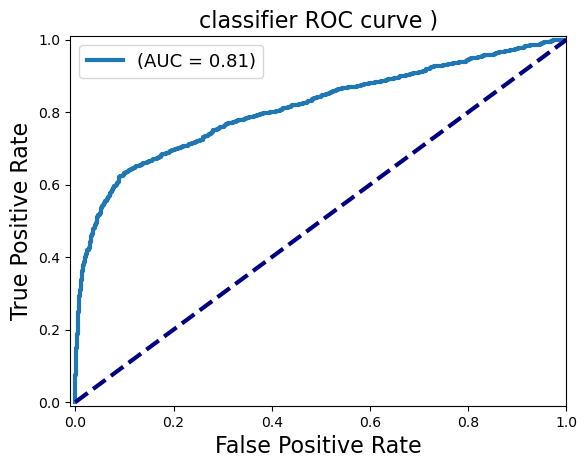

--------------------------------------------Support Vector Machine-------------------------------------
---Confusion Matrix---
 [[ 925 1717]
 [  99  877]]

   Accuracy: 0.50

   Precision: 0.34

   Recall: 0.90

   F1: 0.49
---Classification Report---

   
               precision    recall  f1-score   support

       not 1       0.90      0.35      0.50      2642
           1       0.34      0.90      0.49       976

    accuracy                           0.50      3618
   macro avg       0.62      0.62      0.50      3618
weighted avg       0.75      0.50      0.50      3618

Metric 
 0.90  0.49  0.34  0.50
 0.82


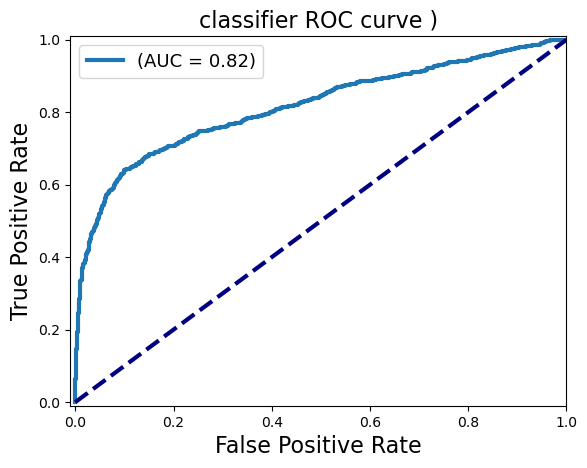

-------------------------------------------Gradient Boosting Tree--------------------------------------------
---Confusion Matrix---
 [[ 101 2541]
 [  12  964]]

   Accuracy: 0.29

   Precision: 0.28

   Recall: 0.99

   F1: 0.43
---Classification Report---

   
               precision    recall  f1-score   support

       not 1       0.89      0.04      0.07      2642
           1       0.28      0.99      0.43       976

    accuracy                           0.29      3618
   macro avg       0.58      0.51      0.25      3618
weighted avg       0.73      0.29      0.17      3618

Metric 
 0.99  0.43  0.28  0.29
 0.82


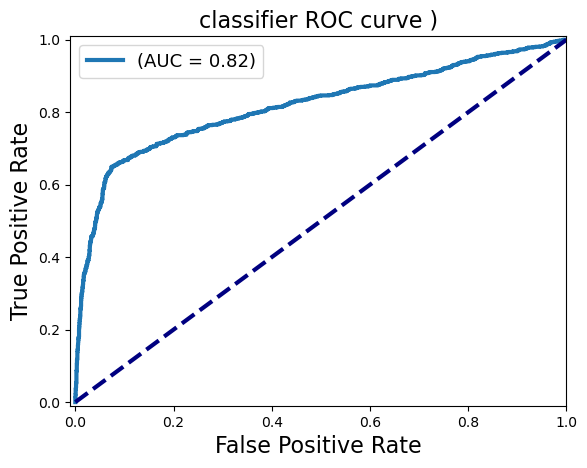

In [29]:
print("--------------------------------------------Logistic Regression---------------------------------------")
lr_fit(X_resampled, y_resampled,X_test,y_test)
print("--------------------------------------------Support Vector Machine-------------------------------------")
svm_rbf_fit(X_resampled, y_resampled,X_test,y_test)
print("-------------------------------------------Gradient Boosting Tree--------------------------------------------")
Gradient_Boosting_fit(X_resampled, y_resampled,X_test,y_test)

# MODEL HYPERPARAMETER TUNING

**TUNING SUPPORT VECTOR MACHINE**

In [30]:
clf = SVC()
grid_values = {'gamma': [   0.1,1,10], 'kernel' : ['linear', 'rbf'],
          'C':[0.1, 1, 10]}

# default metric to optimize over grid parameters: accuracy
grid_clf_acc = GridSearchCV(clf, param_grid = grid_values,cv=3)
grid_clf_acc.fit(X_resampled, y_resampled)
y_decision_fn_scores_acc = grid_clf_acc.decision_function(X_test) 

print('Grid best parameter (max. accuracy): ', grid_clf_acc.best_params_)
print('Grid best score (accuracy): ', grid_clf_acc.best_score_)

# alternative metric to optimize over grid parameters: AUC
grid_clf_auc = GridSearchCV(clf, param_grid = grid_values, cv=3,scoring = 'roc_auc')
grid_clf_auc.fit(X_resampled, y_resampled)
y_decision_fn_scores_auc = grid_clf_auc.decision_function(X_test) 

print('testing set AUC: ', roc_auc_score(y_test, y_decision_fn_scores_auc))
print('Grid best parameter (max. AUC): ', grid_clf_auc.best_params_)
print('Grid best score (AUC): ', grid_clf_auc.best_score_)

# alternative metric to optimize over grid parameters: F-1 socore
grid_clf_f1 = GridSearchCV(clf, param_grid = grid_values, cv=3,scoring = 'f1')
grid_clf_f1.fit(X_resampled, y_resampled)
y_decision_fn_scores_f1 = grid_clf_f1.decision_function(X_test) 


print('Grid best parameter (max. F1): ', grid_clf_f1.best_params_)
print('Grid best score F1: ', grid_clf_f1.best_score_)


Grid best parameter (max. accuracy):  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Grid best score (accuracy):  0.7907706207196128
testing set AUC:  0.8298586980801925
Grid best parameter (max. AUC):  {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Grid best score (AUC):  0.8355597227422166
Grid best parameter (max. F1):  {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Grid best score F1:  0.7633305902674827


**TUNING LOGISTIC REGRESSION**

In [31]:
from sklearn.linear_model import LogisticRegression
    
clf= LogisticRegression()
grid_values = {'max_iter': [100, 300, 500],'C': [ 0.1, 1, 10]}

# default metric to optimize over grid parameters: accuracy
grid_clf_acc = GridSearchCV(clf, param_grid = grid_values,cv=3)
grid_clf_acc.fit(X_resampled, y_resampled)
y_decision_fn_scores_acc = grid_clf_acc.decision_function(X_test) 

print('Grid best parameter (max. accuracy): ', grid_clf_acc.best_params_)
print('Grid best score (accuracy): ', grid_clf_acc.best_score_)

# alternative metric to optimize over grid parameters: AUC
grid_clf_auc = GridSearchCV(clf, param_grid = grid_values, cv=3,scoring = 'roc_auc')
grid_clf_auc.fit(X_resampled, y_resampled)
y_decision_fn_scores_auc = grid_clf_auc.decision_function(X_test) 

print('Testing set AUC: ', roc_auc_score(y_test, y_decision_fn_scores_auc))
print('Grid best parameter (max. AUC): ', grid_clf_auc.best_params_)
print('Grid best score (AUC): ', grid_clf_auc.best_score_)

# alternative metric to optimize over grid parameters: F-1 socore
grid_clf_f1 = GridSearchCV(clf, param_grid = grid_values, cv=3,scoring = 'f1')
grid_clf_f1.fit(X_resampled, y_resampled)
y_decision_fn_scores_f1 = grid_clf_f1.decision_function(X_test) 


print('Grid best parameter (max. F1): ', grid_clf_f1.best_params_)
print('Grid best score F1: ', grid_clf_f1.best_score_)

Grid best parameter (max. accuracy):  {'C': 10, 'max_iter': 100}
Grid best score (accuracy):  0.7702806661757354
Testing set AUC:  0.8185447717203806
Grid best parameter (max. AUC):  {'C': 1, 'max_iter': 100}
Grid best score (AUC):  0.8254657140617087
Grid best parameter (max. F1):  {'C': 1, 'max_iter': 100}
Grid best score F1:  0.7570950820203848


**TUNING GRADIENT BOOSTING TREE**

In [32]:
#'min_samples_leaf':range(100,1000,10),'max_features':range(2,16,2),\'min_samples_split':range(1000,2000,10),\learning rate:
clf =  GradientBoostingClassifier()
grid_values={'n_estimators':range(10,100,30),'max_depth':range(3,10,3),\
        'learning_rate':[0.01,0.1,0.5]}
# default metric to optimize over grid parameters: accuracy
grid_clf_acc = GridSearchCV(clf, param_grid = grid_values,cv=3)
grid_clf_acc.fit(X_resampled, y_resampled)
y_decision_fn_scores_auc = grid_clf_auc.predict_proba(X_test)[:, 1] 
print('Grid best parameter (max. accuracy): ', grid_clf_acc.best_params_)
print('Grid best score (accuracy): ', grid_clf_acc.best_score_)
# alternative metric to optimize over grid parameters: AUC
grid_clf_auc = GridSearchCV(clf, param_grid = grid_values, cv=3,scoring = 'roc_auc')
grid_clf_auc.fit(X_resampled, y_resampled)
y_decision_fn_scores_auc = grid_clf_auc.predict_proba(X_test)[:, 1] 


print('Test set AUC: ', roc_auc_score(y_test, y_decision_fn_scores_auc))
print('Grid best parameter (max. AUC): ', grid_clf_auc.best_params_)
print('Grid best score (AUC): ', grid_clf_auc.best_score_)


Grid best parameter (max. accuracy):  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 40}
Grid best score (accuracy):  0.7889085518427272
Test set AUC:  0.8159654571176826
Grid best parameter (max. AUC):  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 40}
Grid best score (AUC):  0.8446476864280216


# MODEL TRAINING / TESTING - AFTER HYPERPARAMETER TUNING

**FITTING LOGISTIC REGRESSION**

In [33]:
def lr_fit(X_resampled, y_resampled,X_test,y_test):
    lr = LogisticRegression(C=1000, max_iter= 600,penalty= 'l2')
    clf = lr.fit(X_resampled, y_resampled)
    clf_predicted = clf.predict(X_test)
    ConfusionMatrix_Report(y_test=y_test,y_predicted=clf_predicted)
    y_score_lr = lr.decision_function(X_test)
    ROC_decison_function(y_test, y_score=y_score_lr)
    X_resampled=pd.DataFrame(X_resampled,columns=cols)
    print("no inverse scaled coefficient for lr:",clf.coef_)
    feature_importance = abs(clf.coef_[0])
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + .5
    featfig = plt.figure()
    featax = featfig.add_subplot(1, 1, 1)
    featax.barh(pos, feature_importance[sorted_idx], align='center')
    featax.set_yticks(pos)
    featax.set_yticklabels(np.array(X_resampled.columns)[sorted_idx], fontsize=8)
    featax.set_xlabel('Relative Feature Importance')
    plt.tight_layout()   
    plt.show()

---Confusion Matrix---
 [[ 416 2226]
 [  40  936]]

   Accuracy: 0.37

   Precision: 0.30

   Recall: 0.96

   F1: 0.45
---Classification Report---

   
               precision    recall  f1-score   support

       not 1       0.91      0.16      0.27      2642
           1       0.30      0.96      0.45       976

    accuracy                           0.37      3618
   macro avg       0.60      0.56      0.36      3618
weighted avg       0.75      0.37      0.32      3618

Metric 
 0.96  0.45  0.30  0.37
 0.81


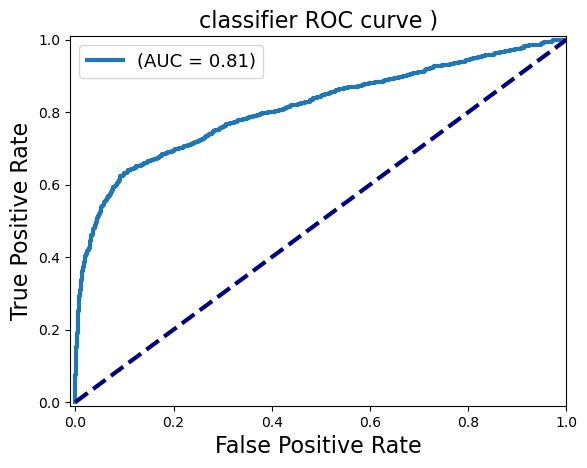

no inverse scaled coefficient for lr: [[ 5.93305734  3.25929221  0.59419921 10.03283395  1.71089001  0.14926798
  -1.42122241  1.87983659  2.25175907 -1.725362    1.41587588 -4.03728587
   1.64716246  2.6169345  -0.22205412 -1.05958592]]


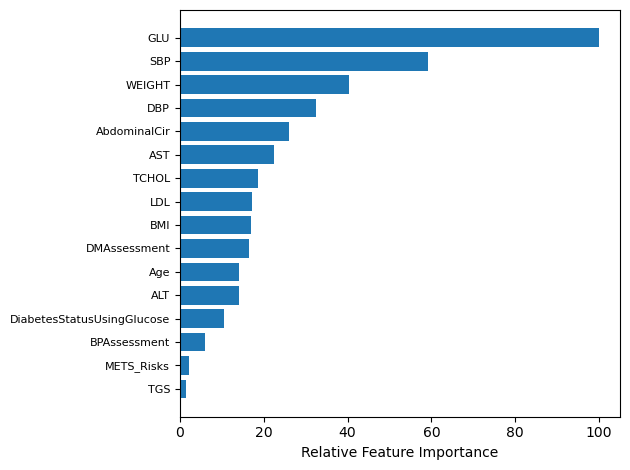

In [34]:
lr_fit(X_resampled, y_resampled,X_test,y_test)

**FITTING GRADIENT BOOSTING TREE**

---Confusion Matrix---
 [[ 145 2497]
 [  18  958]]

   Accuracy: 0.30

   Precision: 0.28

   Recall: 0.98

   F1: 0.43
---Classification Report---

   
               precision    recall  f1-score   support

       not 1       0.89      0.05      0.10      2642
           1       0.28      0.98      0.43       976

    accuracy                           0.30      3618
   macro avg       0.58      0.52      0.27      3618
weighted avg       0.72      0.30      0.19      3618

Metric 
 0.98  0.43  0.28  0.30
 0.82


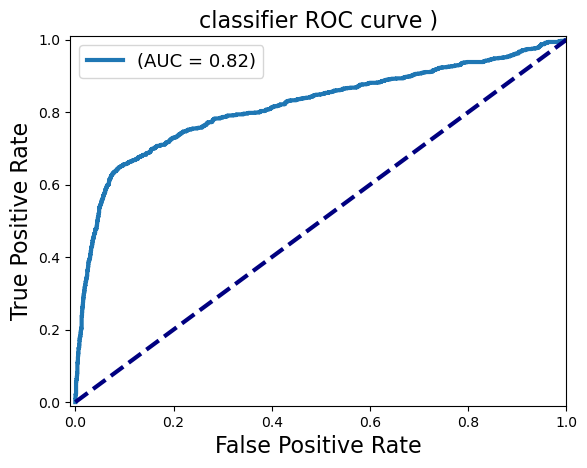

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(learning_rate=0.2, max_depth=3, n_estimators=60).fit(X_resampled, y_resampled)
clf_predicted = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:, 1]
ConfusionMatrix_Report(y_test=y_test,y_predicted=clf_predicted)
ROC_decison_function(y_test, y_score)

In [36]:
def feature_importances_(self):
    total_sum = np.zeros((self.n_features, ), dtype=np.float64)
    for tree in self.estimators_:
        total_sum += tree.feature_importances_ 
    importances = total_sum / len(self.estimators_)
    return importances

 1) BPAssessment      0.400631
 2) DMAssessment      0.282567
 3) GLU               0.056295
 4) DBP               0.055767
 5) SBP               0.051755
 6) METS_Risks        0.027643
 7) BMI               0.019770
 8) Age               0.016034
 9) AbdominalCir      0.015550
10) LDL               0.013239
11) WEIGHT            0.012436
12) ALT               0.012324
13) AST               0.011965
14) TCHOL             0.010105
15) TGS               0.008896
16) DiabetesStatusUsingGlucose 0.005024


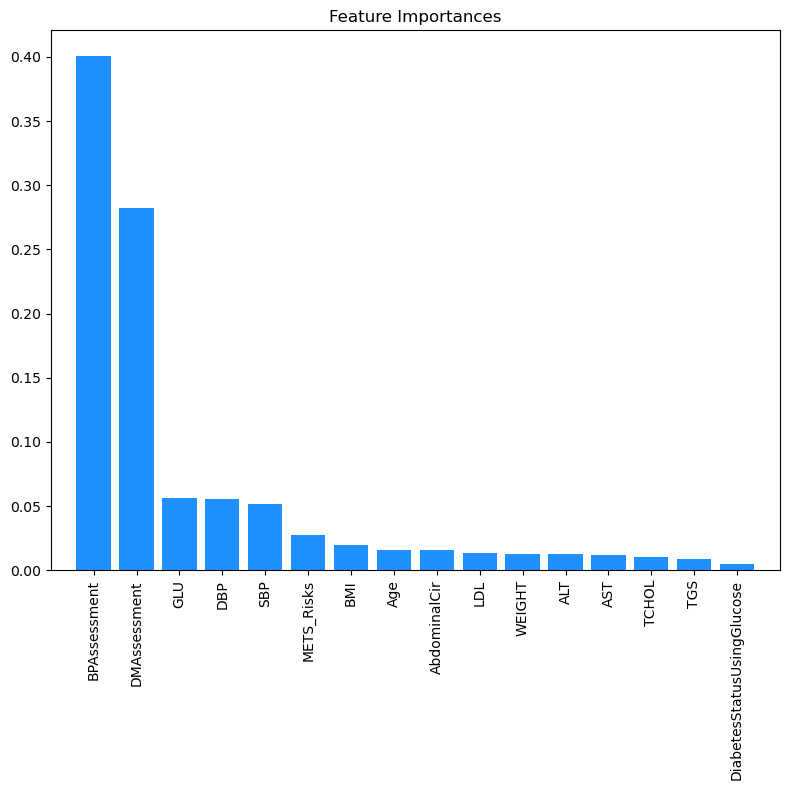

<Figure size 640x480 with 0 Axes>

In [37]:
clf = GradientBoostingClassifier(learning_rate=0.2, max_depth=3, n_estimators=60).fit(X_resampled, y_resampled)
clf_predicted = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:, 1]
importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]
X_resampled= pd.DataFrame(X_resampled)
X_resampled.columns=cols
feat_labels=X_resampled.columns
for f in range(X_test.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 17, 
                            feat_labels[indices[f]], 
                            importances[indices[f]]))
plt.figure(figsize=(8,8), facecolor='white')
plt.title('Feature Importances')
plt.bar(range(X_resampled.shape[1]), 
        importances[indices],
        color='dodgerblue', 
        align='center')

plt.xticks(range(X_resampled.shape[1]), 
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_resampled.shape[1]])
plt.tight_layout()
plt.show()
plt.savefig("Feature_Important_GB")

**FITTING SUPPORT VECTOR MACHINE**

In [38]:
def svm_rbf_fit(X_resampled, y_resampled,X_test,y_test):
    svm_rbf = SVC(kernel='rbf', C=10,gamma=1,probability=True)
    clf = svm_rbf.fit(X_resampled, y_resampled)
    clf_predicted = clf.predict(X_test)
    ConfusionMatrix_Report(y_test=y_test,y_predicted=clf_predicted)
    y_score = svm_rbf.decision_function(X_test)
    ROC_decison_function(y_test, y_score)

---Confusion Matrix---
 [[2191  451]
 [ 280  696]]

   Accuracy: 0.80

   Precision: 0.61

   Recall: 0.71

   F1: 0.66
---Classification Report---

   
               precision    recall  f1-score   support

       not 1       0.89      0.83      0.86      2642
           1       0.61      0.71      0.66       976

    accuracy                           0.80      3618
   macro avg       0.75      0.77      0.76      3618
weighted avg       0.81      0.80      0.80      3618

Metric 
 0.71  0.66  0.61  0.80
 0.81


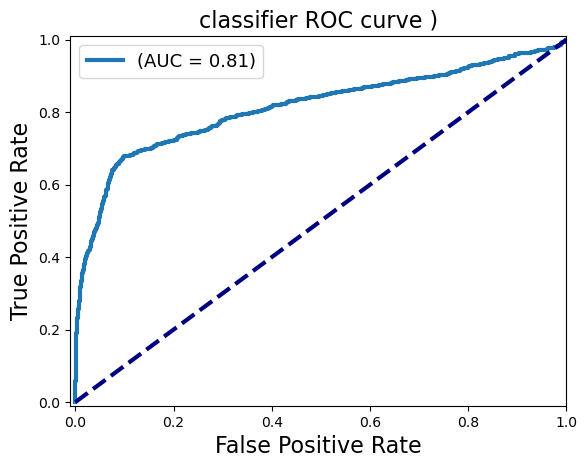

In [39]:
svm_rbf_fit(X_resampled, y_resampled,X_test,y_test)

## Your new classification model below:

In [40]:
# here 

# Clustering

In [41]:
dataset = pd.read_csv('Customers.csv')
X = dataset.iloc[:, [3, 4]].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

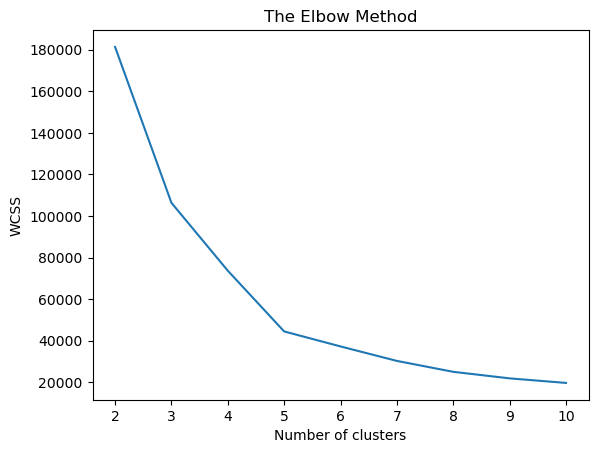

In [43]:
from sklearn.cluster import KMeans
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


plt.plot(range(2, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# There is a method using elbow to select the best hyperparameter on K.
# https://www.scikit-yb.org/en/latest/api/cluster/elbow.html
# please use the metric='silhouette'

## it requires yellowbrick, you can try  pip install yellowbrick, make sure you use the latest version.

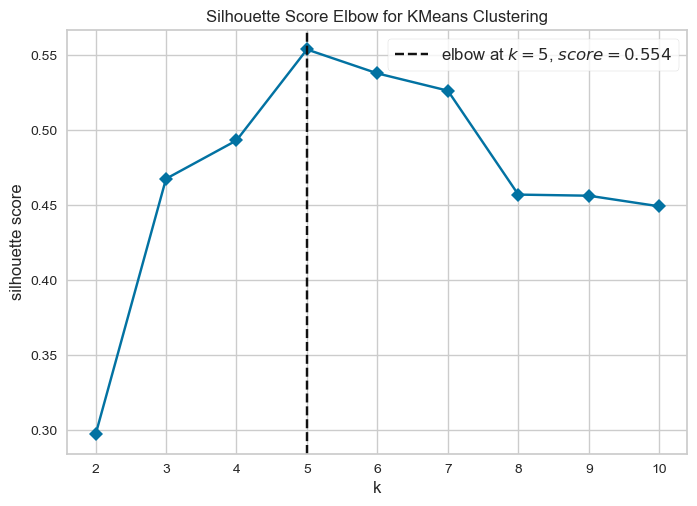

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [44]:
from yellowbrick.cluster import KElbowVisualizer

# Instantiate a scikit-learn K-Means model
model = KMeans(random_state=0)

# Instantiate the KElbowVisualizer with the number of clusters and the metric 
 Your code here
# Fit the data and visualize
  
Your code here

In [113]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [114]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X, kmeans.labels_))

0.553931997444648


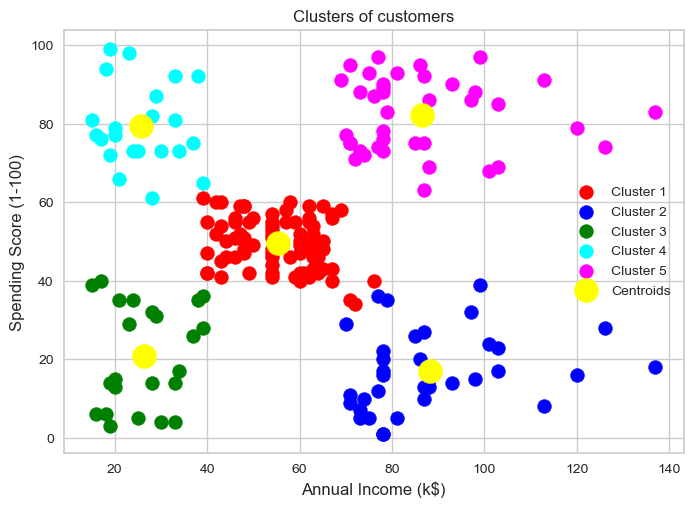

In [115]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()